### Блок 4. Концентрация и диверсификация поставщиков.

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory


#### Подготовка и вспомогательный функции 

In [2]:
conc_data = pd.read_excel('data/final_data.xlsx')
conc_data["rep_date"] = pd.to_datetime(conc_data["rep_date"])
conc_data = conc_data.sort_values(["rep_date", "country", "hs"]).reset_index(drop=True)

shock_date = pd.Timestamp("2022-02-01")

save_dir = "figures/eda_block_4"
os.makedirs(save_dir, exist_ok=True)

In [3]:
def human_format(x, pos):
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def apply_style(ax, title, ylabel=None, xlabel=None, shade_post=False, top=False, post_sanctions=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if shade_post:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        if top:
            if post_sanctions:
                ax.text(
                    x_text, 0.94,
                    "Постсанкционный период",
                    transform=trans,
                    color="#8B0000",
                    fontsize=10,
                    ha="right",
                    va="top",
                    linespacing=1.0
                )
        else: 
            if post_sanctions: 
                ax.text(
                    x_right - 0.1 * (x_right - x_left), 0.04,
                    "Постсанкционный период",
                    transform=trans,
                    color="#8B0000",
                    fontsize=10,
                    ha="right",
                    va="bottom",
                    linespacing=1.0
                )

def save_figure(fig, filename):
    fig.savefig(os.path.join(save_dir, f"{filename}.png"), dpi=400, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [4]:
country_month = (
    conc_data.groupby(["rep_date", "country"], as_index=False)["value"]
    .sum()
)

country_month = country_month.sort_values(["rep_date", "value"], ascending=[True, False]).reset_index(drop=True)

# Общий импорт по месяцу
month_totals = (
    country_month.groupby("rep_date", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "month_total"})
)

country_month = country_month.merge(month_totals, on="rep_date", how="left")

# Доля страны в месячном импорте
country_month["share"] = np.where(
    country_month["month_total"] > 0,
    country_month["value"] / country_month["month_total"],
    0
)

display(country_month.head())

,rep_date,country,value,month_total,share
0,2019-01-01,Germany,7.282748e+07,2.631455e+08,0.276758
1,2019-01-01,USA,3.055282e+07,2.631455e+08,0.116106
2,2019-01-01,China,2.676908e+07,2.631455e+08,0.101727
3,2019-01-01,Netherlands,2.141232e+07,2.631455e+08,0.081371
4,2019-01-01,Lithuania,1.255547e+07,2.631455e+08,0.047713


In [5]:
def concentration_metrics(group):
    g = group[group["value"] > 0].copy()
    
    if g.empty:
        return pd.Series({
            "hhi_10000": np.nan,
            "hhi_raw": np.nan,
            "effective_suppliers": np.nan,
            "cr3_pct": np.nan,
            "cr5_pct": np.nan,
            "nsup": 0
        })
    
    shares = g["share"].values
    shares_sorted = np.sort(shares)[::-1]
    
    hhi_raw = np.sum(shares ** 2)
    hhi_10000 = hhi_raw * 10000
    effective_suppliers = 1 / hhi_raw if hhi_raw > 0 else np.nan
    cr3_pct = shares_sorted[:3].sum() * 100
    cr5_pct = shares_sorted[:5].sum() * 100
    nsup = len(g)

    return pd.Series({
        "hhi_10000": hhi_10000,
        "hhi_raw": hhi_raw,
        "effective_suppliers": effective_suppliers,
        "cr3_pct": cr3_pct,
        "cr5_pct": cr5_pct,
        "nsup": nsup
    })

monthly_conc = (
    country_month.groupby("rep_date")
    .apply(concentration_metrics)
    .reset_index()
)

monthly_conc["period"] = np.where(
    monthly_conc["rep_date"] < shock_date,
    "2019–2021",
    "2022–2025"
)

display(monthly_conc.head())

C:\Users\Admin\AppData\Local\Temp\ipykernel_40468\1243078795.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(concentration_metrics)


,rep_date,hhi_10000,hhi_raw,effective_suppliers,cr3_pct,cr5_pct,nsup,period
0,2019-01-01,1187.060268,0.118706,8.424172,49.459107,62.367477,57.0,2019–2021
1,2019-02-01,1088.025742,0.108803,9.190959,48.075002,60.187962,56.0,2019–2021
2,2019-03-01,1036.877720,0.103688,9.644339,49.018672,61.260763,58.0,2019–2021
3,2019-04-01,1152.468352,0.115247,8.677028,51.023515,64.164394,57.0,2019–2021
4,2019-05-01,1111.432379,0.111143,8.997398,50.089213,63.181922,55.0,2019–2021


#### ГРАФИК 1. HHI ВО ВРЕМЕНИ

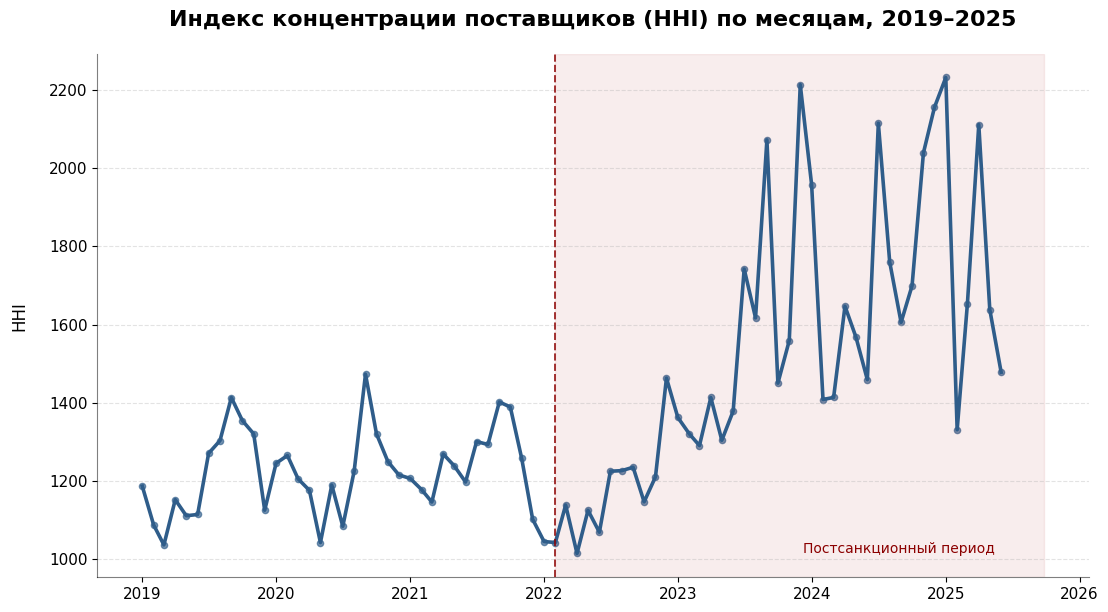

In [7]:
fig, ax = plt.subplots(figsize=(12.8, 6.8))

ax.plot(
    monthly_conc["rep_date"],
    monthly_conc["hhi_10000"],
    color="#2F5D8A",
    linewidth=2.6
)

ax.scatter(
    monthly_conc["rep_date"],
    monthly_conc["hhi_10000"],
    color="#2F5D8A",
    s=20,
    alpha=0.65
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_style(
    ax,
    title="Индекс концентрации поставщиков (HHI) по месяцам, 2019–2025",
    ylabel="HHI",
    shade_post=True
)

save_figure(fig, "01_hhi_monthly")

Динамика индекса HHI показывает, что после 2022 года концентрация импортных поставок заметно усилилась. В 2019–2021 гг. значение индекса в целом оставалось в более низком и относительно стабильном диапазоне, чаще всего около 1050–1450 пунктов, что соответствует умеренной концентрации поставщиков. После начала санкционного периода траектория индекса меняется: сначала сохраняется краткосрочная волатильность, а затем с 2023 года наблюдается явный сдвиг вверх, причем в отдельные месяцы HHI превышает 2000 пунктов. Это означает, что стоимостной импорт медицинского оборудования стал в большей степени зависеть от ограниченного круга стран-поставщиков. Таким образом, несмотря на географическое перераспределение потоков, постсанкционный период сопровождался не расширением, а скорее сужением реально значимых поставщиков.

#### ГРАФИК 2. ЭФФЕКТИВНОЕ ЧИСЛО ПОСТАВЩИКОВ

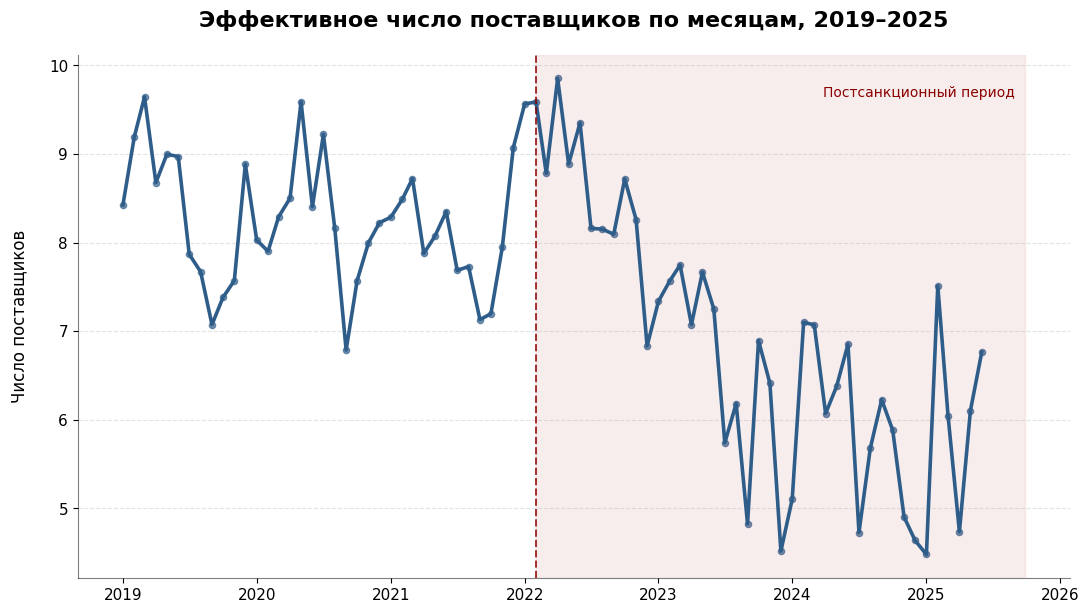

In [9]:
fig, ax = plt.subplots(figsize=(12.8, 6.8))

ax.plot(
    monthly_conc["rep_date"],
    monthly_conc["effective_suppliers"],
    color="#2F5D8A",
    linewidth=2.6
)

ax.scatter(
    monthly_conc["rep_date"],
    monthly_conc["effective_suppliers"],
    color="#2F5D8A",
    s=20,
    alpha=0.65
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_style(
    ax,
    title="Эффективное число поставщиков по месяцам, 2019–2025",
    ylabel="Число поставщиков",
    shade_post=True, top=True
)

save_figure(fig, "02_effective_suppliers_monthly")

График эффективного числа поставщиков подтверждает вывод, полученный из динамики HHI, но в более интуитивной форме. До 2022 года импорт в среднем распределялся между примерно 7–9,5 эффективными поставщиками, причем показатель колебался, но не демонстрировал устойчивого нисходящего тренда. После 2022 года ситуация меняется: уже в 2023–2025 гг. показатель постепенно смещается вниз и в ряде месяцев опускается до 4,5–6. Это означает, что даже если формально поставки продолжаются из большого числа стран, их реальная стоимостная структура все в большей степени определяется небольшим числом ключевых направлений. Следовательно, диверсификация поставщиков в стоимостном выражении после 2022 года сократилась, а импорт стал более зависимым от ограниченного числа доминирующих партнеров.

#### ГРАФИК 3. CR3 И CR5 ПО МЕСЯЦАМ

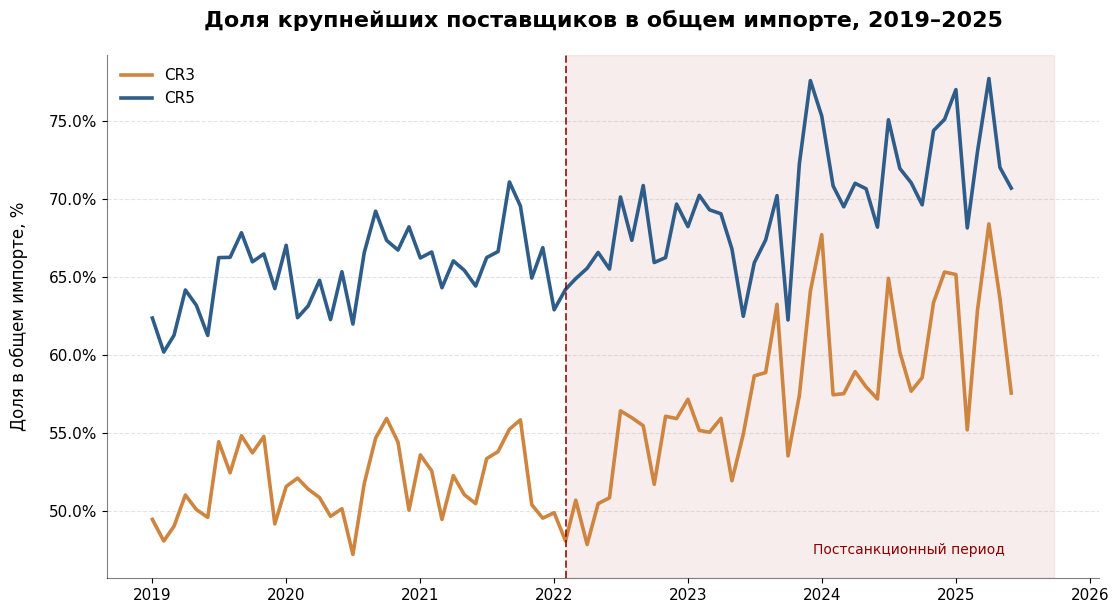

In [11]:
fig, ax = plt.subplots(figsize=(12.8, 6.8))

ax.plot(
    monthly_conc["rep_date"],
    monthly_conc["cr3_pct"],
    color="#CD853F",
    linewidth=2.6,
    label="CR3"
)

ax.plot(
    monthly_conc["rep_date"],
    monthly_conc["cr5_pct"],
    color="#2F5D8A",
    linewidth=2.6,
    label="CR5"
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter())

apply_style(
    ax,
    title="Доля крупнейших поставщиков в общем импорте, 2019–2025",
    ylabel="Доля в общем импорте, %",
    shade_post=True
)

ax.legend(frameon=False, fontsize=11, loc="upper left")

save_figure(fig, "03_cr3_cr5_monthly")

График CR3 и CR5 показывает, что после 2022 года роль крупнейших стран-поставщиков в формировании общего импорта усилилась. В докризисный период на три крупнейшие страны обычно приходилось около 48–56% импорта, а на пять крупнейших — примерно 60–70%. В постсанкционный период обе метрики смещаются вверх: CR3 в ряде месяцев поднимается выше 60–65%, а CR5 нередко достигает 70–78%. Это означает, что все большая часть импорта концентрируется в руках нескольких ведущих поставщиков. При этом особенно важно, что рост CR3 и CR5 наблюдается на устойчивой основе, а не только в виде единичных всплесков, что указывает на структурное, а не случайное усиление концентрации. Иными словами, российский импорт медицинского оборудования после 2022 года стал менее распределенным между многими странами и более завязанным на несколько крупнейших экспортных направлений.

#### ГРАФИК 4. ЧИСЛО АКТИВНЫХ ПОСТАВЩИКОВ

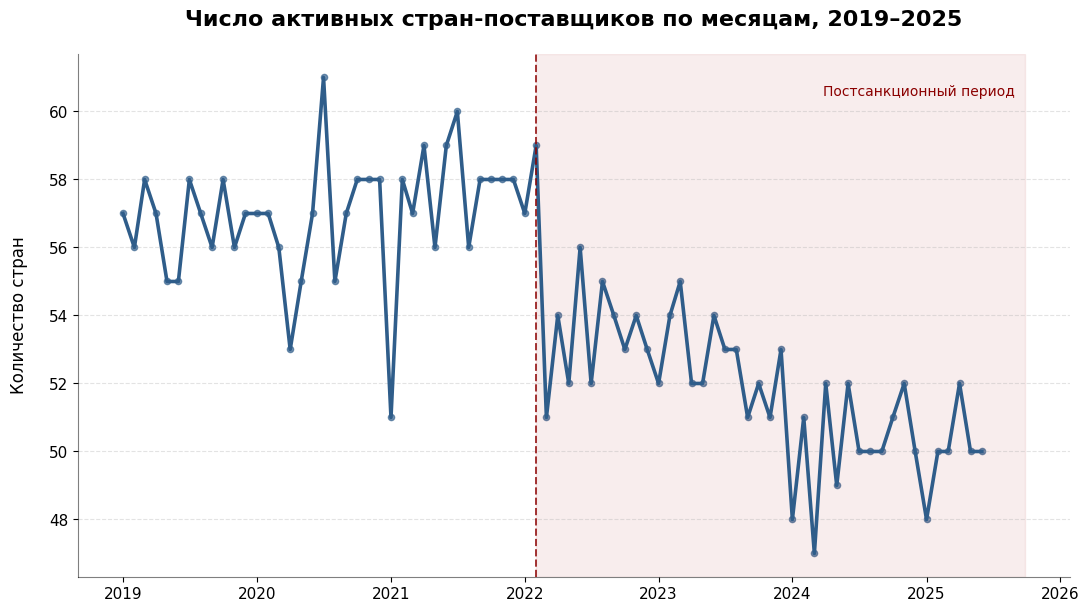

In [14]:
fig, ax = plt.subplots(figsize=(12.8, 6.8))

ax.plot(
    monthly_conc["rep_date"],
    monthly_conc["nsup"],
    color="#2F5D8A",
    linewidth=2.6
)

ax.scatter(
    monthly_conc["rep_date"],
    monthly_conc["nsup"],
    color="#2F5D8A",
    s=20,
    alpha=0.65
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

apply_style(
    ax,
    title="Число активных стран-поставщиков по месяцам, 2019–2025",
    ylabel="Количество стран",
    shade_post=True, top=True
)

save_figure(fig, "04_nsup_monthly")

Динамика числа активных стран-поставщиков показывает, что после 2022 года сократилось не только эффективное число ведущих поставщиков, но и само количество стран, из которых в конкретный месяц поступал положительный импорт. В 2019–2021 гг. число активных стран чаще всего находилось в диапазоне 55–59, а отдельные месяцы даже превышали 60 стран. После начала постсанкционного периода показатель снижается и в дальнейшем в основном колеблется уже около 48–55 стран. Это указывает на то, что часть торговых направлений либо полностью прекратилась, либо стала слишком нерегулярной, чтобы сохраняться в месячной статистике. Таким образом, постсанкционная адаптация сопровождалась не только перераспределением объемов между странами, но и сокращением самого числа устойчиво активных внешнеторговых каналов.

#### ГРАФИК 6. HEATMAP HHI ПО HS И МЕСЯЦАМ

In [15]:
# 5. HHI ПО HS И МЕСЯЦАМ

country_hs_month = (
    conc_data.groupby(["rep_date", "hs", "country"], as_index=False)["value"]
    .sum()
)

hs_month_totals = (
    country_hs_month.groupby(["rep_date", "hs"], as_index=False)["value"]
    .sum()
    .rename(columns={"value": "hs_month_total"})
)

country_hs_month = country_hs_month.merge(hs_month_totals, on=["rep_date", "hs"], how="left")

country_hs_month["share"] = np.where(
    country_hs_month["hs_month_total"] > 0,
    country_hs_month["value"] / country_hs_month["hs_month_total"],
    0
)

hs_month_hhi = (
    country_hs_month[country_hs_month["value"] > 0]
    .groupby(["rep_date", "hs"])["share"]
    .apply(lambda x: np.sum(x**2) * 10000)
    .reset_index(name="hhi_10000")
)

display(hs_month_hhi.head())

,rep_date,hs,hhi_10000
0,2019-01-01,9018,1408.375280
1,2019-01-01,9019,2268.671004
2,2019-01-01,9020,2023.159655
3,2019-01-01,9021,1233.845549
4,2019-01-01,9022,1641.635503


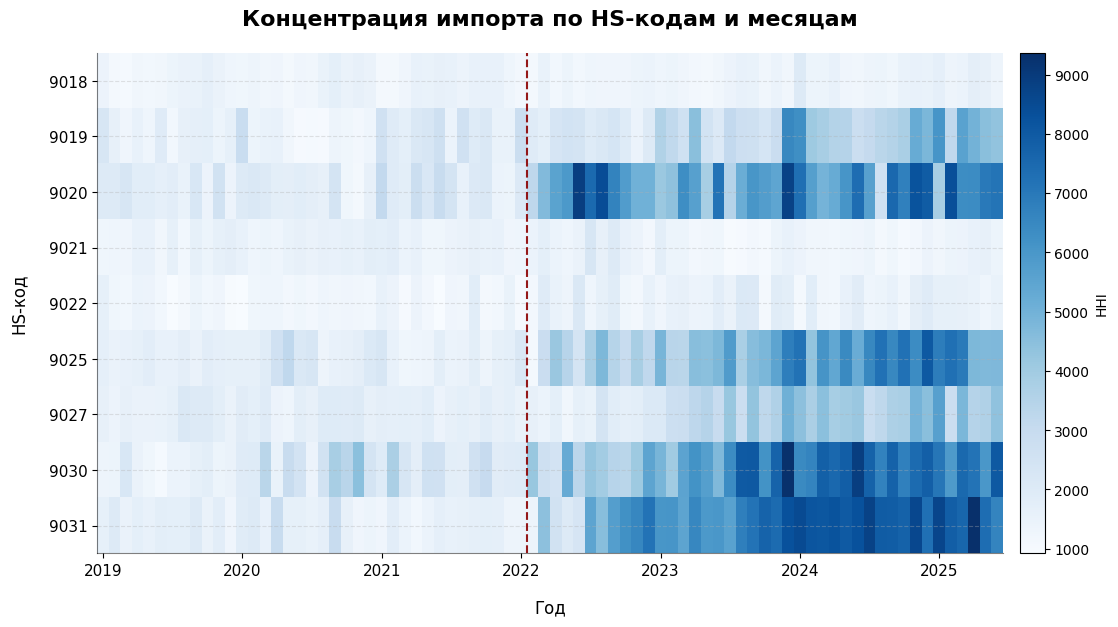

In [21]:
heatmap_hhi = (
    hs_month_hhi.pivot(index="hs", columns="rep_date", values="hhi_10000")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 6.5))

im = ax.imshow(
    heatmap_hhi,
    aspect="auto",
    cmap="Blues"
)

# Подписи Y
ax.set_yticks(np.arange(len(heatmap_hhi.index)))
ax.set_yticklabels(heatmap_hhi.index.astype(str), fontsize=10)

# Подписи X - январь каждого года
date_cols = heatmap_hhi.columns
year_positions = [i for i, d in enumerate(date_cols) if d.month == 1]
year_labels = [str(date_cols[i].year) for i in year_positions]

ax.set_xticks(year_positions)
ax.set_xticklabels(year_labels, fontsize=10)

apply_style(
    ax,
    title="Концентрация импорта по HS-кодам и месяцам",
    ylabel="HS-код",
    xlabel="Год"
)

shock_idx = np.where(date_cols >= shock_date)[0][0]
ax.axvline(shock_idx - 0.5, color="#8B0000", linestyle="--", linewidth=1.5, alpha=0.9)

cbar = fig.colorbar(im, ax=ax, pad=0.015)
cbar.ax.set_ylabel("HHI", fontsize=10)

save_figure(fig, "05_hhi_heatmap_hs_month")

Heatmap по HS-кодам показывает, что усиление концентрации после 2022 года было неоднородным по товарным категориям. Наиболее заметный рост HHI в постсанкционный период наблюдается по кодам 9020, 9025, 9030 и особенно 9031, где окраска становится значительно темнее уже с 2022–2023 гг. и сохраняется до конца периода. Это означает, что именно в этих категориях импорт стал в большей степени зависеть от ограниченного круга поставщиков. В то же время по ряду других кодов, например 9018, 9021 и 9022, уровень концентрации остается сравнительно умеренным и изменяется слабее, что указывает на более устойчивую или более диверсифицированную структуру поставок. Следовательно, рост концентрации после 2022 года нельзя считать полностью универсальным: он был особенно выражен в отдельных товарных сегментах медицинского оборудования, что подтверждает гипотезу о неоднородности санкционного эффекта по категориям HS.

#### ТАБЛИЦА 1. СРЕДНИЕ МЕТРИКИ ДО И ПОСЛЕ 2022 ГОДА

In [20]:
conc_summary = (
    monthly_conc.groupby("period", as_index=False)
    .agg(
        mean_hhi=("hhi_10000", "mean"),
        median_hhi=("hhi_10000", "median"),
        mean_effective_suppliers=("effective_suppliers", "mean"),
        mean_cr3=("cr3_pct", "mean"),
        mean_cr5=("cr5_pct", "mean"),
        mean_nsup=("nsup", "mean")
    )
)

conc_summary

,period,mean_hhi,median_hhi,mean_effective_suppliers,mean_cr3,mean_cr5,mean_nsup
0,2019–2021,1221.751837,1215.783675,8.247752,51.726672,65.287995,56.945946
1,2022–2025,1534.136659,1459.243142,6.834001,57.684897,69.753753,51.878049
